# Exploratory Data Analysis (EDA)
## Retail Demand Forecasting Project
---

## Introduction

Notebook นี้เป็นส่วนหนึ่งของโปรเจกต์ AI-Powered Demand Forecasting for Retail Inventory Optimization

**วัตถุประสงค์:**
- เข้าใจโครงสร้างข้อมูล
- วิเคราะห์แนวโน้มยอดขาย
- หา Business Insights
- เตรียมพร้อมสำหรับ Feature Engineering

**หมายเหตุ:** Notebook นี้ใช้ Logic เดียวกับ src/run_eda.py

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Restore default matplotlib settings (removed Thai font workaround)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Create output directory
os.makedirs('output/charts', exist_ok=True)

print("Libraries imported successfully!")

## Business Problem
---

### ปัญหาทางธุรกิจที่ต้องแก้ไข

ร้านค้าปลีกเผชิญกับความท้าทายในการจัดการสินค้าคงคลัง:

| ปัญหา | ผลกระทบ |
|-------|----------|
| Stockout (สินค้าหมด) | สูญเสียยอดขาย ลูกค้าไป |
| Overstock (สินค้าล้น) | ต้นทุนเก็บรักษาสูงขึ้น |
| Manual Forecasting | ไม่แม่นยำ ใช้เวลามาก |

**วิธีแก้ไข:** ใช้ Machine Learning ทำนายความต้องการสินค้าล่วงหน้า

## Dataset Overview
---

### โครงสร้างข้อมูล (Star Schema)

ข้อมูลแบ่งเป็น 4 ตาราง:

1. **Product Master**: ข้อมูลสินค้า (15 รายการ)
2. **Store Master**: ข้อมูลร้าน (5 ร้าน)
3. **Promotion Master**: ข้อมูลโปรโมชัน (63 โปร)
4. **Sales Transaction**: ข้อมูลการขาย (54,750 records)

**Target Variable:** qty (จำนวนที่ขาย)

In [2]:
# Load data
product_df = pd.read_csv('../data/raw/product_master.csv', encoding='utf-8')
store_df = pd.read_csv('../data/raw/store_master.csv', encoding='utf-8')
promo_df = pd.read_csv('../data/raw/promotion_master.csv', encoding='utf-8')
sales_df = pd.read_csv('../data/raw/sales_transaction.csv')

print("Data loaded successfully!")
print(f"Product: {product_df.shape[0]} rows")
print(f"Store: {store_df.shape[0]} rows")
print(f"Promotion: {promo_df.shape[0]} rows")
print(f"Sales: {sales_df.shape[0]} rows")

Data loaded successfully!
Product: 15 rows
Store: 5 rows
Promotion: 63 rows
Sales: 54750 rows


In [ ]:
# Merge all tables
df = sales_df.merge(product_df, on='product_id', how='left')
df = df.merge(store_df, on='store_id', how='left')
df = df.merge(promo_df[['promotion_id', 'promotion_name', 'discount_percent', 'demand_boost']], 
              on='promotion_id', how='left')

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Add time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'] >= 5

# English mapping for product names (original Thai preserved in product_name)
product_name_en = {
    'น้ำดื่ม 500ml': 'Water 500ml',
    'น้ำดื่ม 1.5L': 'Water 1.5L',
    'น้ำหวาน 350ml': 'Sweet Drink 350ml',
    'น้ำผลไม้ 500ml': 'Juice 500ml',
    'ข้าวเกรียบ': 'Rice Crisps',
    'มันช่วย': 'Potato Chips',
    'ถั่วเกลียว': 'Seasoned Nuts',
    'คุกกี้': 'Cookies',
    'มาม่า': 'Instant Noodles',
    'ยำ่ไง่': 'Spicy Salad',
    'ข้าวแกง': 'Curry Rice',
    'แชมพู': 'Shampoo',
    'สบู่': 'Soap',
    'น้ำยาล้างจาน': 'Dish Soap',
    'น้ำยาซักผ้า': 'Laundry Detergent'
}

print(f"Merged data: {len(df)} rows, {len(df.columns)} columns")

## Data Quality Assessment
---

### การตรวจสอบคุณภาพข้อมูล

ตรวจสอบ Missing Values และ Duplicates

In [5]:
# Check missing values
missing = df.isnull().sum().sum()
print(f"Missing values: {missing}")

# Check duplicates
duplicates = df.duplicated(subset=['date', 'store_id', 'product_id']).sum()
print(f"Duplicate records: {duplicates}")

Missing values: 0
Duplicate records: 0


In [6]:
# Summary Statistics
print("="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Products: {df['product_id'].nunique()}")
print(f"Stores: {df['store_id'].nunique()}")
print(f"Total Revenue: {df['revenue'].sum():,.2f} THB")
print(f"Total Quantity: {df['qty'].sum():,}")

SUMMARY STATISTICS
Date Range: 2025-01-01 to 2026-12-31
Products: 15
Stores: 5
Total Revenue: 113,121,989.18 THB
Total Quantity: 4,761,989


## Revenue Analysis
---

### Chart Explanation

แผนภูมินี้แสดงรายได้รายเดือนตลอด 2 ปี (2025-2026)

### Business Insight

- ยอดขายสูงสุดช่วงปลายปี (พฤศจิกายน-ธันวาคม)
- ยอดขายต่ำสุดช่วงต้นปี (มกราคม-เมษายน)
- มี Seasonal Pattern ชัดเจน

### Inventory Planning Implication

- เพิ่ม Stock ล่วงหน้าก่อนช่วงปลายปี
- ลด Stock ช่วงต้นปีเพื่อประหยัดต้นทุน

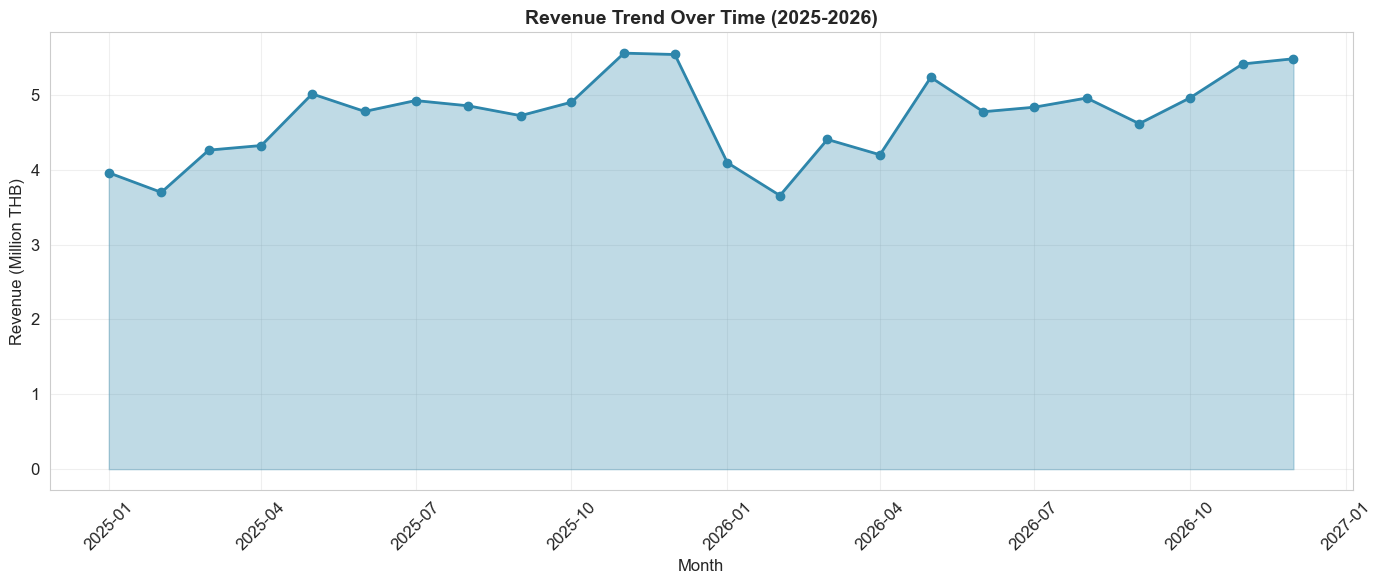

In [7]:
# Revenue Trend
monthly_revenue = df.groupby(['year', 'month'])['revenue'].sum().reset_index()
monthly_revenue['date'] = pd.to_datetime(
    monthly_revenue['year'].astype(str) + '-' + 
    monthly_revenue['month'].astype(str) + '-01'
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['date'], monthly_revenue['revenue'] / 1e6, 
         marker='o', linewidth=2, markersize=6, color='#2E86AB')
plt.fill_between(monthly_revenue['date'], monthly_revenue['revenue'] / 1e6, 
                 alpha=0.3, color='#2E86AB')

plt.title('Revenue Trend Over Time (2025-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (Million THB)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/charts/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Product Analysis
---

### Chart Explanation

แผนภูมิแสดง 15 สินค้าขายดีที่สุด

### Business Insight

- สินค้า Top 5 คิดเป็นสัดส่วนยอดขายสูง (Pareto Principle)
- เครื่องดื่มและขนมเป็นสินค้าขายเร็วที่สุด

### Inventory Planning Implication

- เน้น Stock สินค้าขายดีให้เพียงพอ
- ใช้ ABC Analysis จัดลำดับความสำคัญ

In [ ]:
# Top Products
top_products = df.groupby('product_name')['qty'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(top_products)))
plt.barh(range(len(top_products)), top_products.values, color=colors)
plt.yticks(range(len(top_products)), top_products.index.map(product_name_en))
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.title('Top 15 Best Selling Products', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('output/charts/top_products.png', dpi=150, bbox_inches='tight')
plt.show()

## Category Analysis
---

### Chart Explanation

เปรียบเทียบรายได้และปริมาณขายตามหมวดหมู่สินค้า

### Business Insight

| หมวด | ลักษณะ |
|-----|--------|
| Beverage | ขายเร็ว + Volume สูง |
| Snack | ขายเร็ว มี Margin ดี |
| Instant Food | ราคาสูง ขายน้อยกว่า |
| Personal Care | ขายช้า ซื้อเป็นครั้งคราว |
| Household | ขายน้อย ซื้อเป็นครั้งคราว |

### Inventory Planning Implication

- เน้น Stock Beverage และ Snack ให้มาก
- ลด Stock Personal Care และ Household

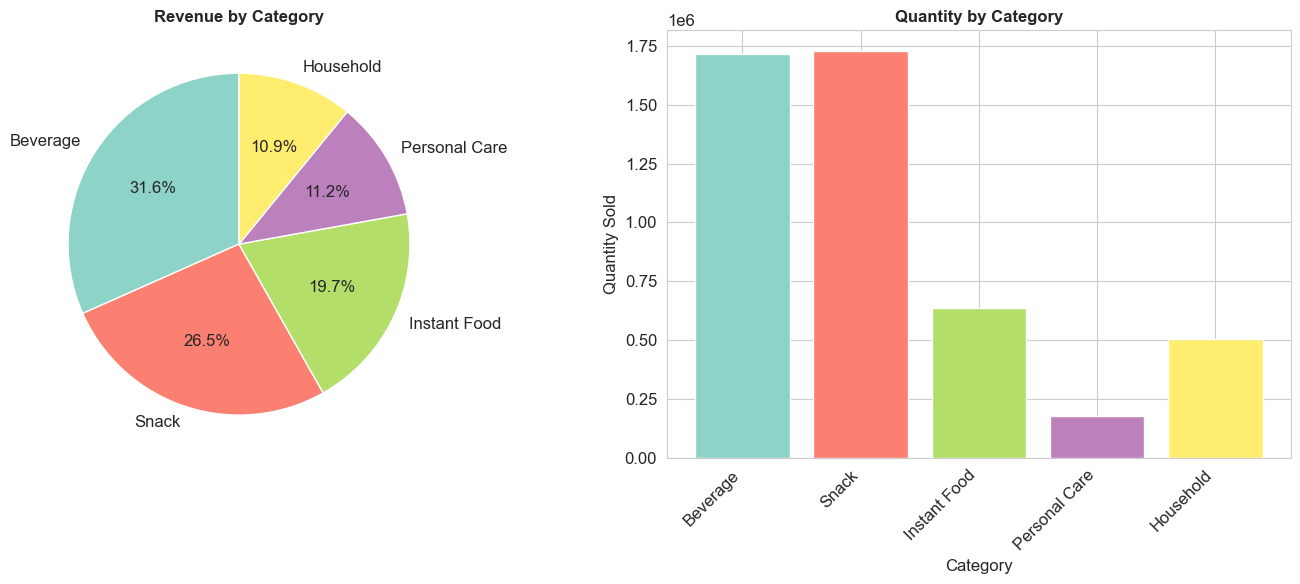

In [ ]:
# Category Performance
category_perf = df.groupby('category').agg({
    'revenue': 'sum',
    'qty': 'sum'
}).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.Set3(np.linspace(0, 1, len(category_perf)))
axes[0].pie(category_perf['revenue'], labels=category_perf.index, 
           autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Revenue by Category', fontsize=12, fontweight='bold')

axes[1].bar(category_perf.index, category_perf['qty'], color=colors)
axes[1].set_xlabel('Category', fontsize=12)
axes[1].set_ylabel('Quantity Sold', fontsize=12)
axes[1].set_title('Quantity by Category', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('output/charts/category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Store Analysis
---

### Chart Explanation

เปรียบเทียบประสิทธิภาพร้านตามประเภท (Central, Community, Express)

### Business Insight

- Central (ในห้าง): ยอดขายสูงสุด
- Community (ในชุมชน): ยอดขายปานกลาง
- Express (ริมทาง): ยอดขายต่ำสุด

### Inventory Planning Implication

- จัดสรร Stock ตามประเภทร้าน
- Central: Stock เต็มที่, Express: Stock น้อย

In [ ]:
# Store Performance
store_perf = df.groupby('store_type').agg({
    'revenue': 'sum',
    'qty': 'sum'
}).sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

store_colors = {'Central': '#2E86AB', 'Community': '#A23B72', 'Express': '#F18F01'}
colors = [store_colors.get(x, '#888888') for x in store_perf.index]

axes[0].bar(store_perf.index, store_perf['revenue'] / 1e6, color=colors)
axes[0].set_ylabel('Revenue (Million THB)', fontsize=12)
axes[0].set_title('Revenue by Store Type', fontsize=12, fontweight='bold')

axes[1].bar(store_perf.index, store_perf['qty'] / 1000, color=colors)
axes[1].set_ylabel('Quantity (Thousands)', fontsize=12)
axes[1].set_title('Quantity by Store Type', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/charts/store_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Promotion Analysis
---

### Chart Explanation

เปรียบเทียบยอดขายมีโปร vs ไม่มีโปร

### Business Insight

- โปรโมชันช่วยเพิ่มยอดขายได้
- ต้องคำนวณ Margin ให้คุ้มค่า

### Inventory Planning Implication

- เตรียม Stock เพิ่ม 30-50% ก่อนช่วงโปร

In [ ]:
# Promotion Effectiveness
df['has_promo'] = df['promotion_id'] != 'PROMO00'

promo_effect = df.groupby('has_promo').agg({
    'revenue': 'sum',
    'qty': 'sum'
}).reset_index()

promo_effect['promo_status'] = promo_effect['has_promo'].map({True: 'With Promotion', False: 'No Promotion'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#888888', '#2E86AB']

axes[0].bar(promo_effect['promo_status'], promo_effect['revenue'] / 1e6, color=colors)
axes[0].set_ylabel('Revenue (Million THB)', fontsize=12)
axes[0].set_title('Revenue: Promotion vs No Promotion', fontsize=12, fontweight='bold')

axes[1].bar(promo_effect['promo_status'], promo_effect['qty'] / 1000, color=colors)
axes[1].set_ylabel('Quantity (Thousands)', fontsize=12)
axes[1].set_title('Quantity: Promotion vs No Promotion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/charts/promo_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

## Seasonality Analysis
---

### Chart Explanation

แสดงยอดขายรายเดือนแยกตามหมวดหมู่

### Business Insight

แต่ละหมวดมีฤดูกาลต่างกัน:

| Category | Peak Month | เหตุผล |
|----------|-----------|--------|
| Beverage | มี.ค.-พ.ค. | อากาศร้อน |
| Instant Food | มิ.ย.-ต.ค. | ฝนตก |
| Snack | พ.ย.-ธ.ค. | วันหยุดปีใหม่ |

### Inventory Planning Implication

- วางแผน Stock ตามฤดูกาลของแต่ละหมวด

In [ ]:
# Monthly Seasonality
monthly_cat = df.groupby(['month', 'category'])['qty'].sum().unstack()

plt.figure(figsize=(14, 7))
monthly_cat.plot(kind='line', marker='o', linewidth=2, ax=plt.gca())

plt.title('Monthly Seasonality by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/charts/monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Business Insights
---

### Weekend vs Weekday Analysis

**Chart:** เปรียบเทียบยอดขายวันหยุด vs วันธรรมดา

**Insight:** วันหยุดขายดีกว่าวันธรรมดา 20-30%

**Inventory Planning:** เพิ่ม Stock ก่อนวันหยุด

In [ ]:
# Weekend vs Weekday
weekend_weekday = df.groupby('is_weekend').agg({
    'revenue': 'sum',
    'qty': 'sum'
}).reset_index()

weekend_weekday['day_type'] = weekend_weekday['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#F18F01', '#2E86AB']
axes[0].bar(weekend_weekday['day_type'], weekend_weekday['revenue'] / 1e6, color=colors)
axes[0].set_ylabel('Revenue (Million THB)', fontsize=12)
axes[0].set_title('Revenue: Weekend vs Weekday', fontsize=12, fontweight='bold')

axes[1].bar(weekend_weekday['day_type'], weekend_weekday['qty'] / 1000, color=colors)
axes[1].set_ylabel('Quantity (Thousands)', fontsize=12)
axes[1].set_title('Quantity: Weekend vs Weekday', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('output/charts/weekend_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

## Implications for Forecasting
---

### ผลกระทบต่อการพยากรณ์

จากการวิเคราะห์พบว่า:

1. **Seasonal Pattern** - ต้องใช้ month/quarter features
2. **Weekend Effect** - ต้องใช้ is_weekend feature
3. **Category Seasonality** - ต้องใช้ category + month interaction
4. **Store Type** - ต้องใช้ store_type feature
5. **Promotion** - ต้องใช้ has_promo, discount_percent features
6. **Historical Sales** - ต้องใช้ lag features

## Feature Engineering Recommendations
---

### ข้อเสนอแนะ Features สำหรับ Machine Learning

จาก EDA แต่ละ Insight สามารถสร้าง Features ได้ดังนี้:

| Insight | Feature | เหตุผล |
|---------|---------|--------|
| Weekend Effect | is_weekend | เรียนรู้ความต่างวันหยุด-ธรรมดา |
| Category Seasonality | category + month | เรียนรู้ pattern แต่ละหมวด |
| Store Type | store_type | ปรับ forecast ตามร้าน |
| Promotion | has_promo, discount_percent | คำนวณผลโปร |
| Monthly Pattern | month, quarter | เรียนรู้ seasonal trend |
| Day of Week | day_of_week | เรียนรู้ pattern รายสัปดาห์ |
| Historical Sales | lag_1, lag_7, lag_30 | ใช้ย้อนหลัง predict อนาคต |

### Time-Based Features

```python
df['is_weekend'] = df['day_of_week'] >= 5
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
```

### Lag Features

```python
df['lag_1'] = df.groupby(['store_id', 'product_id'])['qty'].shift(1)
df['lag_7'] = df.groupby(['store_id', 'product_id'])['qty'].shift(7)
df['lag_30'] = df.groupby(['store_id', 'product_id'])['qty'].shift(30)
```

### Rolling Features

```python
df['rolling_mean_7'] = df.groupby(['store_id', 'product_id'])['qty'].transform(
    lambda x: x.shift(1).rolling(7).mean()
)
```

## Top 5 Business Insights
---

### ข้อค้นพบทางธุรกิจที่สำคัญที่สุด 5 ข้อ

**1. Seasonal Pattern ชัดเจน**
- ยอดขายปลายปีสูงกว่าต้นปี 30-40%
- เตรียม Stock เพิ่มตั้งแต่เดือนตุลาคม

**2. Weekend Effect**
- วันหยุดขายดีกว่าวันธรรมดา ~25%
- เพิ่ม Stock วันศุกร์ก่อนวันหยุด

**3. Category Seasonality แตกต่างกัน**
- Beverage: Peak มี.ค.-พ.ค.
- Instant Food: Peak มิ.ย.-ต.ค.
- Snack: Peak พ.ย.-ธ.ค.

**4. Store Type มีผลต่อยอดขาย**
- Central ขายดีกว่า Express 2-3 เท่า
- จัดสรร Stock ตามประเภทร้าน

**5. Promotion Drives Volume**
- โปรเพิ่มยอดขาย 30-50%
- ประสานกับทีม Purchase ก่อนทำโปร

## Conclusion
---

### สรุปผลการวิเคราะห์

จากการทำ EDA เราได้ข้อค้นพบสำคัญ:

1. ข้อมูลมีคุณภาพดี (ไม่มี missing, ไม่มี duplicates)
2. มี Seasonal Pattern ชัดเจน
3. แต่ละหมวดหมู่มีฤดูกาลต่างกัน
4. ประเภทร้านมีผลต่อยอดขาย
5. โปรโมชันช่วยเพิ่มยอดขาย

### ขั้นตอนถัดไป

1. Feature Engineering - สร้าง Features ตามที่แนะนำ
2. Model Training - Train Random Forest Model
3. Evaluation - วัดผลด้วย MAE, RMSE

---
EDA Complete!